Dataset head:
            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


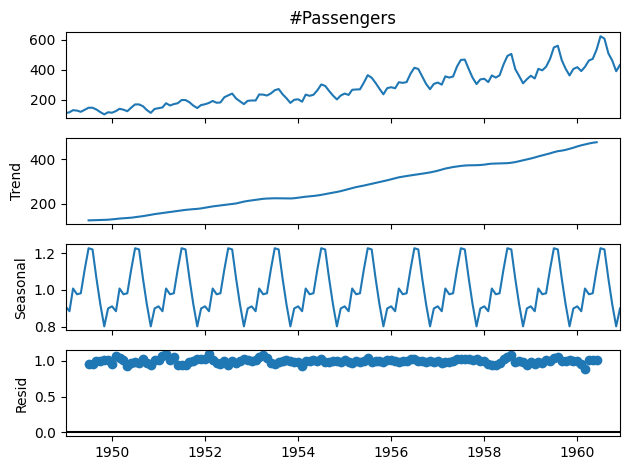

In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

# Step 1: Load the AirPassengers dataset
data = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\AirPassengers.csv", index_col='Month', parse_dates=True)
data.index.freq = 'MS' # Set the frequency to Month Start

# Step 2: Display the first few rows
print("Dataset head:")
print(data.head())

# Step 3: ETS Decomposition
result = seasonal_decompose(data['#Passengers'], model='multiplicative')
result.plot()
plt.show()

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
Critical Values:
 1%: -3.4816817173418295
 5%: -2.8840418343195267
 10%: -2.578770059171598


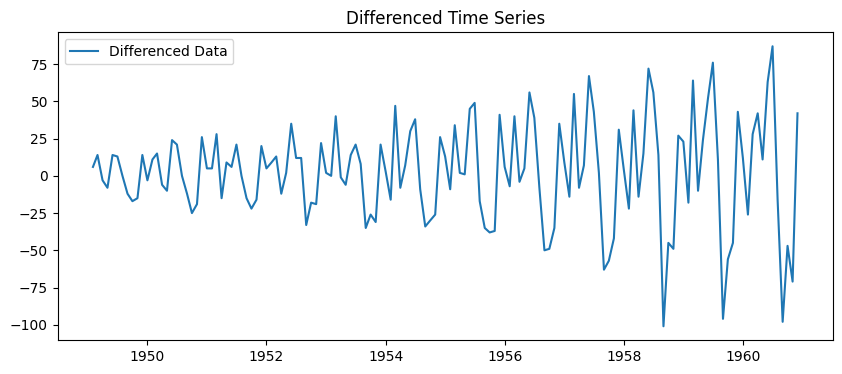

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=1.92 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.22 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=1.29 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.63 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=1.24 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.35 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.39 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.96 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.96 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=1.57 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.12 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.09 sec
 ARIMA(3,1,1)(0,1,0

In [2]:
# Step 4: Stationarity check using the Augmented Dickey-Fuller (ADF) test
adf_test = adfuller(data['#Passengers'])
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print("Critical Values:")
for key, value in adf_test[4].items():
 print(f" {key}: {value}")
    
# Step 5: Differencing to make the data stationary if necessary
data_diff = data['#Passengers'].diff().dropna()
plt.figure(figsize=(10, 4))
plt.plot(data_diff, label='Differenced Data')
plt.title('Differenced Time Series')
plt.legend()
plt.show()

# Step 6: Auto ARIMA to identify optimal parameters
auto_model = auto_arima(data['#Passengers'], seasonal=True, m=12, trace=True, stepwise=True)
print(f"Optimal parameters: {auto_model.get_params()}")

In [3]:
# Step 7: Train the ARIMA model
order = auto_model.order
seasonal_order = auto_model.seasonal_order
arima_model = ARIMA(data['#Passengers'], order=order, seasonal_order=seasonal_order)
arima_result = arima_model.fit()

# Step 8: Model summary
print(arima_result.summary())

C:\Program Files\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Program Files\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                     
Dep. Variable:                       #Passengers   No. Observations:                  144
Model:             ARIMA(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                           Wed, 10 Dec 2025   AIC                           1017.847
Time:                                   21:54:18   BIC                           1029.348
Sample:                               01-01-1949   HQIC                          1022.520
                                    - 12-01-1960                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343

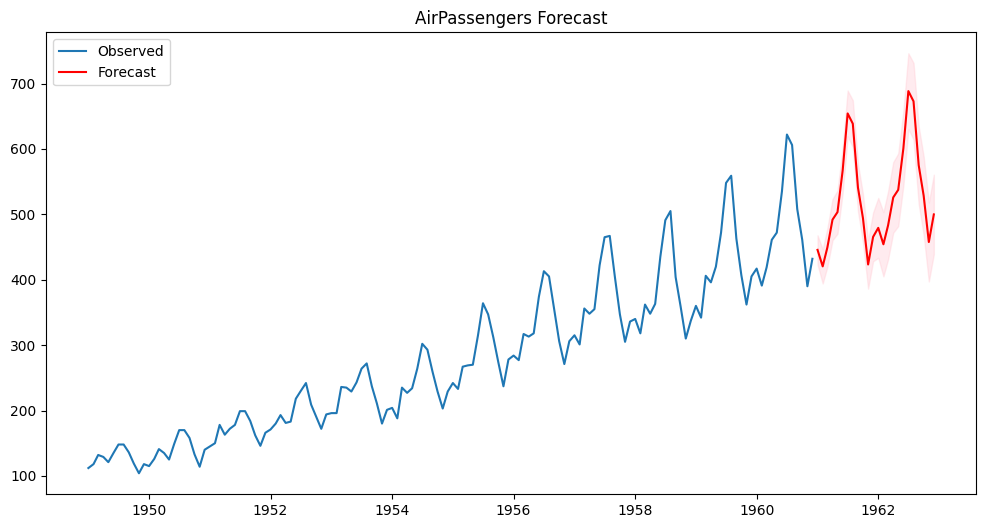

In [4]:
# Step 9: Forecasting
forecast_steps = 24 # Forecast for 2 years
forecast = arima_result.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_steps + 1, freq='MS')[1:]
forecast_series = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Step 10: Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['#Passengers'], label='Observed')
plt.plot(forecast_index, forecast_series, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('AirPassengers Forecast')
plt.legend()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax
from matplotlib.animation import FuncAnimation

In [6]:
# Load the Dataset
data = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\data_for_lr.csv")
print(data)
# Drop the missing values
data = data.dropna()
print(data)

        x          y
0    24.0  21.549452
1    50.0  47.464463
2    15.0  17.218656
3    38.0  36.586398
4    87.0  87.288984
..    ...        ...
695  58.0  58.595006
696  93.0  94.625094
697  82.0  88.603770
698  66.0  63.648685
699  97.0  94.975266

[700 rows x 2 columns]
        x          y
0    24.0  21.549452
1    50.0  47.464463
2    15.0  17.218656
3    38.0  36.586398
4    87.0  87.288984
..    ...        ...
695  58.0  58.595006
696  93.0  94.625094
697  82.0  88.603770
698  66.0  63.648685
699  97.0  94.975266

[699 rows x 2 columns]


In [7]:
# training dataset and labels
train_input = np.array(data.x[0:500]).reshape(500, 1)
train_output = np.array(data.y[0:500]).reshape(500, 1)

# valid dataset and labels
test_input = np.array(data.x[500:700]).reshape(199, 1)
test_output = np.array(data.y[500:700]).reshape(199, 1)

In [8]:
class LinearRegression:
    def __init__(self):
        self.parameters = {}
        
    def forward_propagation(self, train_input):
        m = self.parameters['m']
        c = self.parameters['c']
        predictions = np.multiply(m, train_input) + c
        return predictions
 
    def cost_function(self, predictions, train_output):
        cost = np.mean((train_output - predictions) ** 2)
        return cost
 
    def backward_propagation(self, train_input, train_output, predictions):
        derivatives = {}
        df = (predictions-train_output)
        # dm= 2/n * mean of (predictions-actual) * input
        dm = 2 * np.mean(np.multiply(train_input, df))
        # dc = 2/n * mean of (predictions-actual)
        dc = 2 * np.mean(df)
        derivatives['dm'] = dm
        derivatives['dc'] = dc
        return derivatives
 
    def update_parameters(self, derivatives, learning_rate):
        self.parameters['m'] = self.parameters['m'] - learning_rate * derivatives['dm']
        self.parameters['c'] = self.parameters['c'] - learning_rate * derivatives['dc']
 
    def train(self, train_input, train_output, learning_rate, iters):
        # Initialize random parameters
        self.parameters['m'] = np.random.uniform(0, 1) * -1
        self.parameters['c'] = np.random.uniform(0, 1) * -1
        
        # Initialize loss
        self.loss = []
        
        # Initialize figure and axis for animation
        fig, ax = plt.subplots()
        x_vals = np.linspace(min(train_input), max(train_input), 100)
        line, = ax.plot(x_vals, self.parameters['m'] * x_vals + self.parameters['c'], color='red', label='Regression Line')
        ax.scatter(train_input, train_output, marker='o', color='green', label='Training Data')
        
        # Set y-axis limits to exclude negative values
        ax.set_ylim(0, max(train_output) + 1)
 
        def update(frame):
            # Forward propagation
            predictions = self.forward_propagation(train_input)
 
            # Cost function
            cost = self.cost_function(predictions, train_output)
 
            # Back propagation
            derivatives = self.backward_propagation(train_input, train_output, predictions)
 
            # Update parameters
            self.update_parameters(derivatives, learning_rate)
 
            # Update the regression line
            line.set_ydata(self.parameters['m'] * x_vals + self.parameters['c'])
 
            # Append loss and print
            self.loss.append(cost)
            print("Iteration = {}, Loss = {}".format(frame + 1, cost))
            return line,
 
        # Create animation
        ani = FuncAnimation(fig, update, frames=iters, interval=200, blit=True)
 
        # Save the animation as a video file (e.g., MP4)
        ani.save('linear_regression_A.gif', writer='ffmpeg')
 
        plt.xlabel('Input')
        plt.ylabel('Output')
        plt.title('Linear Regression')
        plt.legend()
        plt.show()
    
        return self.parameters, self.loss

MovieWriter ffmpeg unavailable; using Pillow instead.


Iteration = 1, Loss = 6712.124908649338
Iteration = 1, Loss = 815.7687613019915
Iteration = 1, Loss = 105.1936768357059
Iteration = 1, Loss = 19.56164556026939
Iteration = 2, Loss = 9.242053239750348
Iteration = 3, Loss = 7.998429413342837
Iteration = 4, Loss = 7.848558561257842
Iteration = 5, Loss = 7.830496845590165
Iteration = 6, Loss = 7.8283195653605215
Iteration = 7, Loss = 7.8280565325313125
Iteration = 8, Loss = 7.8280241874111365
Iteration = 9, Loss = 7.828019642735558
Iteration = 10, Loss = 7.828018448381251
Iteration = 11, Loss = 7.828017657842269
Iteration = 12, Loss = 7.82801691603257
Iteration = 13, Loss = 7.828016180160414
Iteration = 14, Loss = 7.828015445068929
Iteration = 15, Loss = 7.828014710136647
Iteration = 16, Loss = 7.828013975288664
Iteration = 17, Loss = 7.82801324051595
Iteration = 18, Loss = 7.82801250581741
Iteration = 19, Loss = 7.828011771192907
Iteration = 20, Loss = 7.828011036642415


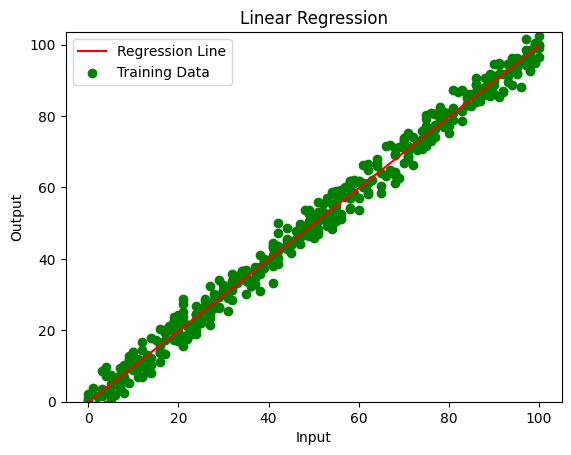

In [9]:
#Example usage
linear_reg = LinearRegression()
parameters, loss = linear_reg.train(train_input, train_output, 0.0001, 20)

In [4]:
# import the necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# load the breast cancer dataset
X, y = load_breast_cancer(return_X_y=True)

# split the train and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=23)

# LogisticRegression
clf = LogisticRegression(random_state=0, max_iter = 5000)
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Logistic Regression model accuracy (in %):", acc*100)

Logistic Regression model accuracy (in %): 96.49122807017544


In [1]:
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics

# load the digit dataset
digits = datasets.load_digits()

# defining feature matrix(X) and response vector(y)
X = digits.data
y = digits.target

# splitting X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

# create logistic regression object
reg = linear_model.LogisticRegression(max_iter = 2000)

# train the model using the training sets
reg.fit(X_train, y_train)

# making predictions on the testing set
y_pred = reg.predict(X_test)

# comparing actual response values (y_test) with predicted response values (y_pred)
print("Logistic Regression model accuracy(in %):", metrics.accuracy_score(y_test, y_pred)*100)

Logistic Regression model accuracy(in %): 96.66203059805285


Training Range: 2014-01-06 00:00:00 to 2017-11-30 00:00:00
Testing Range:  2017-12-01 00:00:00 to 2017-12-30 00:00:00

Model Performance (MAPE): 151781686160373.06%


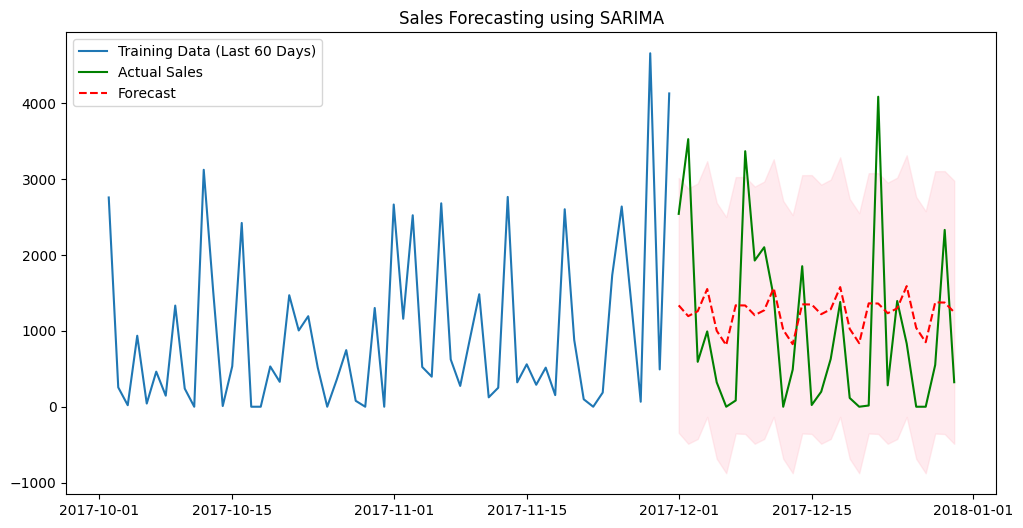

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

df_sales = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex1- time series\stores_sales_forecasting.csv", encoding='latin1')

df_sales['Order Date'] = pd.to_datetime(df_sales['Order Date'])
daily_sales = df_sales.groupby('Order Date')['Sales'].sum()

daily_sales = daily_sales.asfreq('D').fillna(0)

train_size = len(daily_sales) - 30
train_sales = daily_sales.iloc[:train_size]
test_sales = daily_sales.iloc[train_size:]

print(f"Training Range: {train_sales.index.min()} to {train_sales.index.max()}")
print(f"Testing Range:  {test_sales.index.min()} to {test_sales.index.max()}")

model_sarima = SARIMAX(train_sales,
                       order=(1, 1, 1),
                       seasonal_order=(0, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit(disp=False)

forecast = results_sarima.get_forecast(steps=len(test_sales))
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

epsilon = 1e-10
y_true = test_sales.values
y_pred = forecast_values.values
mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

print(f"\nModel Performance (MAPE): {mape:.2f}%")

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_sales.index[-60:], train_sales.values[-60:], label='Training Data (Last 60 Days)')
plt.plot(test_sales.index, test_sales.values, label='Actual Sales', color='green')
plt.plot(test_sales.index, forecast_values, label='Forecast', color='red', linestyle='--')
plt.fill_between(test_sales.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title("Sales Forecasting using SARIMA")
plt.legend()
plt.show()

Temperature Data Range: 1981-01-01 00:00:00 to 1990-12-31 00:00:00


C:\Program Files\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Program Files\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Program Files\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Program Files\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Program Files\Pytho


Best ARIMA Order found: (3, 0, 1)
Best AIC Score: 16777.73

Forecast for next 5 days:
1991-01-01    12.989070
1991-01-02    13.328509
1991-01-03    13.487153
1991-01-04    13.510724
1991-01-05    13.491581
Freq: D, Name: predicted_mean, dtype: float64


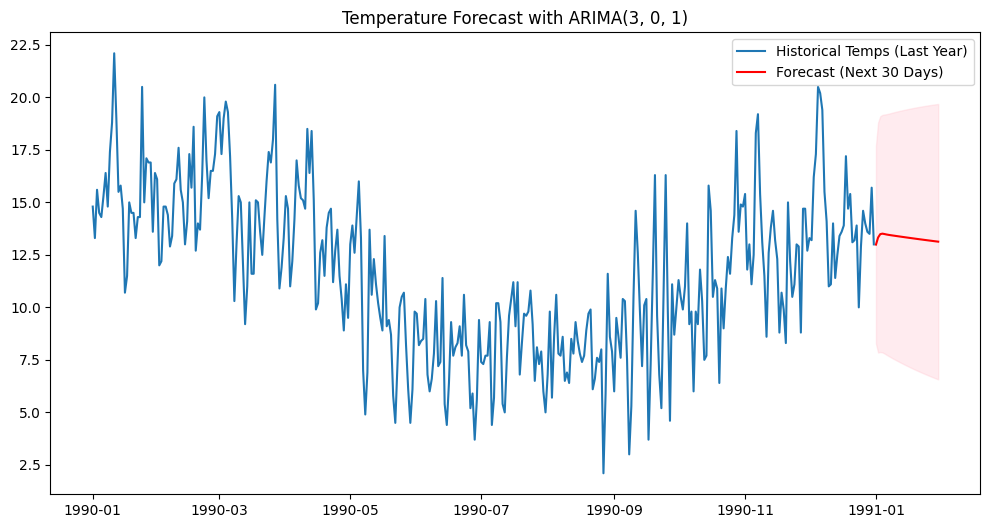

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

df_temp = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex1- time series\daily-min-temperatures.csv")
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp = df_temp.set_index('Date').asfreq('D')

print(f"Temperature Data Range: {df_temp.index.min()} to {df_temp.index.max()}")

best_aic = float("inf")
best_order = None
best_model = None

p_values = range(0, 4)  # AR terms
d_values = range(0, 2)  # Differencing
q_values = range(0, 3)  # MA terms

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Fit ARIMA model
                model = ARIMA(df_temp['Temp'], order=(p, d, q))
                results = model.fit()
                
                # Check if this model is better (lower AIC is better)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
                    best_model = results
            except:
                continue

print(f"\nBest ARIMA Order found: {best_order}")
print(f"Best AIC Score: {best_aic:.2f}")

forecast_steps = 30
forecast_res = best_model.get_forecast(steps=forecast_steps)
forecast_vals = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

print("\nForecast for next 5 days:")
print(forecast_vals.head())

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(df_temp.index[-365:], df_temp['Temp'].tail(365), label='Historical Temps (Last Year)')
plt.plot(forecast_vals.index, forecast_vals, label='Forecast (Next 30 Days)', color='red')
plt.fill_between(forecast_vals.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title(f"Temperature Forecast with ARIMA{best_order}")
plt.legend()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
df_housing = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex2- linear regression\BostonHousing.csv")
    
if df_housing.isnull().sum().sum() > 0:
    df_housing.dropna(inplace=True)
    
if 'medv' in df_housing.columns:
    target_col = 'medv'
else:
    target_col = df_housing.columns[-1]
        
X = df_housing.drop(columns=[target_col])
y = df_housing[target_col]
    
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
# 3. Train Model
model_housing = LinearRegression()
model_housing.fit(X_train, y_train)
    
# 4. Evaluate
y_pred = model_housing.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
    
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 20.69
R-squared (R2): 0.7200


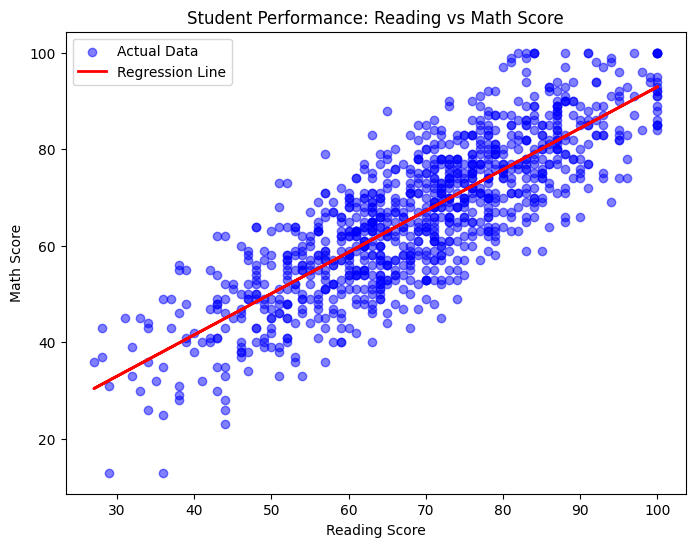

Coefficient (Slope): 0.86
Intercept: 7.30


In [23]:
df_students = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex2- linear regression\Student_exams.csv")

X_students = df_students[['reading score']]
y_students = df_students['math score']

# 3. Train Model
model_student = LinearRegression()
model_student.fit(X_students, y_students)

# 4. Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_students, y_students, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_students, model_student.predict(X_students), color='red', linewidth=2, label='Regression Line')
plt.title("Student Performance: Reading vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.legend()
plt.show()

print(f"Coefficient (Slope): {model_student.coef_[0]:.2f}")
print(f"Intercept: {model_student.intercept_:.2f}")

In [24]:
df_co2 = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex2- linear regression\co2.csv")

features = ['Engine Size(L)', 'Fuel Consumption Comb (L/100 km)']
target = 'CO2 Emissions(g/km)'

X_co2 = df_co2[features]
y_co2 = df_co2[target]

# Split Data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_co2, y_co2, test_size=0.2, random_state=42)

# 3. Train Model
model_co2 = LinearRegression()
model_co2.fit(X_train_c, y_train_c)

# 4. Evaluate
y_pred_c = model_co2.predict(X_test_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
r2_c = r2_score(y_test_c, y_pred_c)

# Adjusted R-squared calculation
n = len(y_test_c)
p = X_test_c.shape[1]
adj_r2_c = 1 - (1 - r2_c) * (n - 1) / (n - p - 1)

print(f"RMSE: {rmse_c:.2f}")
print(f"Adjusted R-squared: {adj_r2_c:.4f}")

RMSE: 21.05
Adjusted R-squared: 0.8710


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_titanic = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex3- logistic regression\Titanic-Dataset.csv")

cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_titanic.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)

df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace=True)

le_sex = LabelEncoder()
df_titanic['Sex'] = le_sex.fit_transform(df_titanic['Sex'])

le_embarked = LabelEncoder()
df_titanic['Embarked'] = le_embarked.fit_transform(df_titanic['Embarked'])

X_titanic = df_titanic.drop(columns=['Survived'])
y_titanic = df_titanic['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

scaler_t = StandardScaler()
X_train_t = scaler_t.fit_transform(X_train_t)
X_test_t = scaler_t.transform(X_test_t)

model_titanic = LogisticRegression(max_iter=1000)
model_titanic.fit(X_train_t, y_train_t)

y_pred_t = model_titanic.predict(X_test_t)
y_prob_t = model_titanic.predict_proba(X_test_t)[:, 1]

roc_auc = roc_auc_score(y_test_t, y_prob_t)
f1 = f1_score(y_test_t, y_pred_t)

print(f"Titanic AUC-ROC Score: {roc_auc:.4f}")
print(f"Titanic F1 Score:      {f1:.4f}")

In [ ]:
df_brca = pd.read_csv(r"C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 6\Ex3- logistic regression\brca.csv")

if 'Unnamed: 0' in df_brca.columns:
    df_brca.drop(columns=['Unnamed: 0'], inplace=True)

le_brca = LabelEncoder()
df_brca['y'] = le_brca.fit_transform(df_brca['y'])

X_brca = df_brca.drop(columns=['y'])
y_brca = df_brca['y']

# Split Data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_brca, y_brca, test_size=0.2, random_state=42)

# Scale Data
scaler_b = StandardScaler()
X_train_b = scaler_b.fit_transform(X_train_b)
X_test_b = scaler_b.transform(X_test_b)

# 3. Train Model
model_brca = LogisticRegression(max_iter=1000)
model_brca.fit(X_train_b, y_train_b)

# 4. Evaluate (Accuracy, Precision, Recall)
y_pred_b = model_brca.predict(X_test_b)

accuracy_b = accuracy_score(y_test_b, y_pred_b)
precision_b = precision_score(y_test_b, y_pred_b)
recall_b = recall_score(y_test_b, y_pred_b)

print(f"BRCA Accuracy:  {accuracy_b:.4f}")
print(f"BRCA Precision: {precision_b:.4f}")
print(f"BRCA Recall:    {recall_b:.4f}")

Training Logistic Regression on Digits...


C:\Program Files\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


MNIST Accuracy: 0.9046
Confusion Matrix:
[[ 940    0    7    2    0   14    9    2    4    2]
 [   0 1103    6    3    1    3    4    2   13    0]
 [   5   12  899   17    8    6   15   12   52    6]
 [   4    1   26  898    2   35    4   12   19    9]
 [   2    4    6    1  905    1   15    5    9   34]
 [   9    2    4   47    9  752   17    2   38   12]
 [   8    3   11    0   14   16  899    3    4    0]
 [   0   10   21   10    8    1    0  943    5   30]
 [   5   15   12   31    7   30   12   10  837   15]
 [   6    9    2   10   52   10    1   41    8  870]]


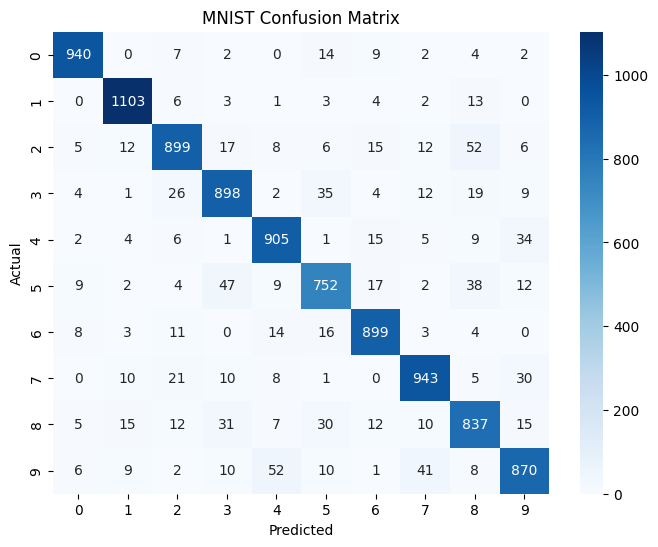

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist

(X_train_m, y_train_m), (X_test_m, y_test_m) = mnist.load_data()

n_pixels = 28 * 28
X_train_m = X_train_m.reshape((-1, n_pixels))
X_test_m = X_test_m.reshape((-1, n_pixels))

X_train_m = X_train_m.astype("float32") / 255.0
X_test_m = X_test_m.astype("float32") / 255.0

limit = 10000
X_train_m = X_train_m[:limit]
y_train_m = y_train_m[:limit]

# 3. Train Model (Multinomial Logistic Regression)
# 'multinomial' option is handled automatically by sklearn's LogisticRegression
print("Training Logistic Regression on Digits...")
model_mnist = LogisticRegression(max_iter=300, solver='lbfgs', multi_class='multinomial')
model_mnist.fit(X_train_m, y_train_m)

# 4. Evaluate (Accuracy, Confusion Matrix)
y_pred_m = model_mnist.predict(X_test_m)
accuracy_m = accuracy_score(y_test_m, y_pred_m)
conf_matrix_m = confusion_matrix(y_test_m, y_pred_m)

print(f"MNIST Accuracy: {accuracy_m:.4f}")
print("Confusion Matrix:")
# Simple print or heatmap
print(conf_matrix_m)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_m, annot=True, fmt='d', cmap='Blues')
plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()